In [1]:
from util import parse_json_file, query_with_macro_state, naive_query
file_path = 'example1.json'  # Path to your JSON file

    # Parse JSON file
parsed_graph, parsed_attributes, parsed_automaton, global_vars = parse_json_file(file_path)
query_with_macro_state(parsed_graph, parsed_attributes, parsed_automaton, 1, 1, global_vars)
# naive_query(parsed_automaton,parsed_graph, global_vars,1,1,parsed_attributes)

From: 1, To: 1, Formula: (assert(and (> age p1)(> p1 10)))
From: 1, To: 2, Formula: (assert(> p1 10))
[And(30 > p1, p1 > ToReal(10))]
[And(p1 <= 29, p1 >= 11), And(25 > p1, p1 > ToReal(10))]
[And(p1 <= 24, p1 >= 11), p1 > ToReal(10)]


[('p1', 11.0, 24.0)]

In [1]:
from z3 import *
a = Real("a")
b = Real("b")
solver = Optimize()
solver.add(a>1.0)
h = solver.minimize(a)
solver.check()
a:z3.ArithRef = solver.lower(h)
EPSILON = a.children()[1]
val = z3.substitute(a, (z3.Const("epsilon", RealSort()), RealVal(0.0001)) )
z3.simplify(val)

10001/10000

In [2]:
from property_graph import generate_and_dump
generate_and_dump(200000, 1000, "pgraph/graph-2000000-10000.json")


         edge:
            {0: [('favorite', 137), ('follow', 582), ('followanymously', 867), ('follow', 821), ('follow', 782), ('follow', 64), ('favorite', 261), ('follow', 120), ('favorite', 507), ('follow', 779), ('favorite', 460), ('follow', 483), ('followanymously', 667), ('follow', 388), ('favorite', 807), ('favorite', 214), ('follow', 96), ('follow', 499), ('follow', 29), ('favorite', 914), ('followanymously', 855), ('follow', 399), ('followanymously', 443), ('favorite', 622), ('followanymously', 780), ('followanymously', 785), ('favorite', 2), ('favorite', 712), ('followanymously', 456), ('favorite', 272), ('favorite', 738), ('favorite', 996), ('follow', 234), ('follow', 605), ('favorite', 104), ('favorite', 923), ('favorite', 325), ('favorite', 31), ('follow', 22), ('favorite', 26), ('follow', 665), ('favorite', 554), ('followanymously', 9), ('followanymously', 902), ('follow', 390), ('followanymously', 702), ('favorite', 221), ('follow', 432), ('follow', 743), ('follow', 981

Text(0, 0.5, 'Time(s)')

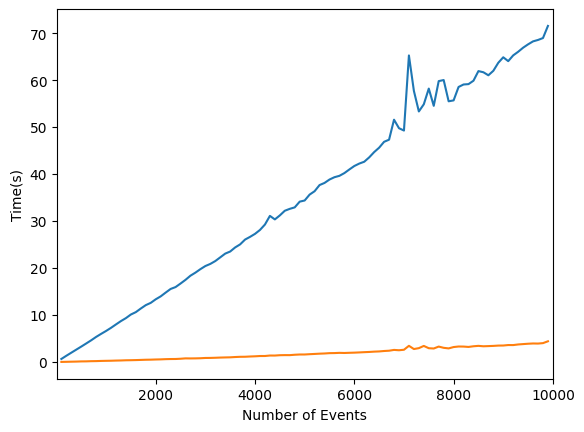

In [ ]:
import pickle as pkl
import matplotlib.pyplot as plt 
a = pkl.load(open('sat.pkl', 'rb'))
result = list(map(lambda x:(x[1],x[2]), a))
baseline = list(map(lambda x: x[0]* 100, a))
plt.plot(baseline, result)
plt.xlabel("Number of Events")
plt.xlim((10, 10000))
plt.ylabel("Time(s)")

In [1]:
from nra_util import query_property_graph
from property_graph import load_graph
from parametric_automata import load_automata
import time

auto = load_automata("pauto/auto3.json")
graph10k = load_graph("pgraph/graph-2000000-10000.json")
graph1k= load_graph("pgraph/graph-200000-1000.json")
graph200= load_graph("pgraph/graph-10000-200.json")

graph10k_time = []
graph1k_time = []
graph200_time = []
for i in range(200):
    start = time.time()
    product_iter = query_property_graph(graph10k, auto, i)
    end = time.time()
    graph10k_time.append(end - start)
    start = time.time()
    product_iter = query_property_graph(graph1k, auto, i)
    end = time.time()
    graph1k_time.append(end - start)
    start = time.time()
    product_iter = query_property_graph(graph200, auto, i)
    end = time.time()
    graph200_time.append(end - start)

print(f"""


Graph 10k avg time: {sum(graph10k_time)/len(graph10k_time)}
Graph 1k avg time: {sum(graph1k_time)/len(graph1k_time)}
Graph 200 avg time: {sum(graph200_time)/len(graph200_time)}

""")





Graph 10k avg time: 0.16857722282409668
Graph 1k avg time: 0.16873666644096375
Graph 200 avg time: 0.04570648789405823




In [7]:
from nra_util import query_property_graph
from property_graph import load_graph
from parametric_automata import load_automata
import time

auto = load_automata("pauto/auto1.json")
graph10k = load_graph("pgraph/graph-2000000-10000.json")
graph1k= load_graph("pgraph/graph-200000-1000.json")
graph200= load_graph("pgraph/graph-10000-200.json")

graph10k_time = []
graph1k_time = []
graph200_time = []
for i in range(200):
    start = time.time()
    product_iter = query_property_graph(graph10k, auto, i)
    end = time.time()
    graph10k_time.append(end - start)
    start = time.time()
    product_iter = query_property_graph(graph1k, auto, i)
    end = time.time()
    graph1k_time.append(end - start)
    start = time.time()
    product_iter = query_property_graph(graph200, auto, i)
    end = time.time()
    graph200_time.append(end - start)

print(f"""


Graph 10k avg time: {sum(graph10k_time)/len(graph10k_time)}
Graph 1k avg time: {sum(graph1k_time)/len(graph1k_time)}
Graph 200 avg time: {sum(graph200_time)/len(graph200_time)}

""")




Graph 10k avg time: 0.09998895645141602
Graph 1k avg time: 0.09996368408203125
Graph 200 avg time: 0.023994059562683107




In [20]:
import sympy as sp
import diofant
x, y = diofant.symbols('x y', real=True)
eqns = [x**2 * y**2 <= x**2 * y, x**2 * y**2 > x**2 * y]
# reduced_eqns = simplify(eqns) 
# reduced_eqns
print(diofant.solve(eqns))

ValueError: Only expressions or equalities supported, got x**2*y**2 <= x**2*y

[]

In [2]:
from z3 import *
x = Real('x')
y = Real('y')
s = Solver()
s.add(2*x*x + 4*y < 0)
s.add(3*x*x + 4*y*y*x*x < 0)
s.check()

unsat

14.37722586659061